### Install all required libraries on top of the rapids image

In [1]:
%%capture
!pip install pytorch
!pip install torchvision 
!pip install torchsummary
!pip install imblearn
!pip install mlxtend
!pip install opencv-python
!apt-get install libgl1 --yes
!pip install onnx
!pip install snowflake-snowpark-python[pandas]
!pip install snowflake-ml-python

### Import all required libraries. CV2 is not utlized but is being imported for testing the snowflake udf

In [1]:
import os
import random
import numpy as np 
import pandas as pd
import json
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
%matplotlib inline

# import cv2
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

from PIL import *
from tqdm import tqdm
from torchsummary import summary
from torchvision import datasets, transforms
from torch.utils.data import  DataLoader, Dataset, ConcatDataset
from sklearn.model_selection import train_test_split

from snowflake.snowpark import Session
from snowflake.snowpark.version import VERSION
from snowflake.snowpark.types import StructType, StructField, FloatType, StringType, IntegerType, List
import snowflake.snowpark.functions as Fn

### Include gpus/multigpus when using the snowpark container services

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


### Unzip the chest xray dataset and save it on the disk

In [4]:
%%capture
!unzip data/chest_xray.zip

In [3]:
train_folder= 'chest_xray/chest_xray/train/'
val_folder = 'chest_xray/chest_xray/val/'
test_folder = 'chest_xray/chest_xray/test/'

### Define Data Augmentation on the DICOM images (jpegs)

In [4]:
data_transforms = {
    'train': {
        'dataset1': transforms.Compose([transforms.Resize(255),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.RandomGrayscale(),
            transforms.RandomAffine(translate=(0.05,0.05), degrees=0),
            transforms.ToTensor()
           ]),

        'dataset2' : transforms.Compose([transforms.Resize(255),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=1),
            transforms.RandomGrayscale(),
            transforms.RandomAffine(translate=(0.1,0.05), degrees=10),
            transforms.ToTensor()

           ]),
        'dataset3' : transforms.Compose([transforms.Resize(255),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.RandomGrayscale(p=1),
            transforms.RandomAffine(translate=(0.08,0.1), degrees=15),
            transforms.ToTensor()
           ]),
    },
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

### Split and randomize datasets for training

In [5]:
dataset1 = datasets.ImageFolder(train_folder, 
                      transform=data_transforms['train']['dataset1'])

dataset2 = datasets.ImageFolder(train_folder, 
                      transform=data_transforms['train']['dataset2'])

dataset3 = datasets.ImageFolder(train_folder, 
                      transform=data_transforms['train']['dataset3'])

norm1, _ = train_test_split(dataset2, test_size= 0.75, shuffle=False)
norm2, _ = train_test_split(dataset3, test_size= 0.77, shuffle=False)

In [6]:
dataset = ConcatDataset([dataset1, norm1, norm2])

In [7]:
train_ds, val_ds = train_test_split(dataset, test_size=0.3, random_state=2000)

In [8]:
Datasets = {
    'train': train_ds,
    'test' : datasets.ImageFolder(test_folder, data_transforms['test']),
    'val'  : val_ds
}

### Define Dataloaders for Train, Test and Validate

In [9]:
Dataloaders = {
    'train': DataLoader(Datasets['train'], batch_size = 512, num_workers = 4),
    'test': DataLoader(Datasets['test'], batch_size = 512, shuffle = True, num_workers = 4),
    'val': DataLoader(Datasets['val'], batch_size = 512, shuffle = True, num_workers = 4),
}

### Build Statistics on the dataset. Especially make sure it is balanced dataset

In [10]:
files = []
categories = []
filenames = os.listdir(os.path.join(train_folder,'NORMAL'))
for name in filenames:
    files.append(os.path.join(train_folder, 'NORMAL', name))
    categories.append('NORMAL')

filenames = os.listdir(os.path.join(train_folder,'PNEUMONIA'))
for name in filenames:
    files.append(os.path.join(train_folder, 'PNEUMONIA', name))
    categories.append('PNEUMONIA')

In [11]:
Tr_PNEUMONIA = len([label for _, label in Datasets['train'] if label == 1])
Tr_NORMAL = len(Datasets['train']) - Tr_PNEUMONIA
V_PNEUMONIA = len([label for _, label in Datasets['val'] if label == 1])
V_NORMAL = len(Datasets['val']) - V_PNEUMONIA
Te_PNEUMONIA = len([label for _, label in Datasets['test'] if label == 1])
Te_NORMAL = len(Datasets['test']) - Te_PNEUMONIA
Pn = [Tr_PNEUMONIA, V_PNEUMONIA, Te_PNEUMONIA]
No = [Tr_NORMAL, V_NORMAL, Te_NORMAL]
Pn, No

([2718, 1157, 390], [2685, 1159, 234])

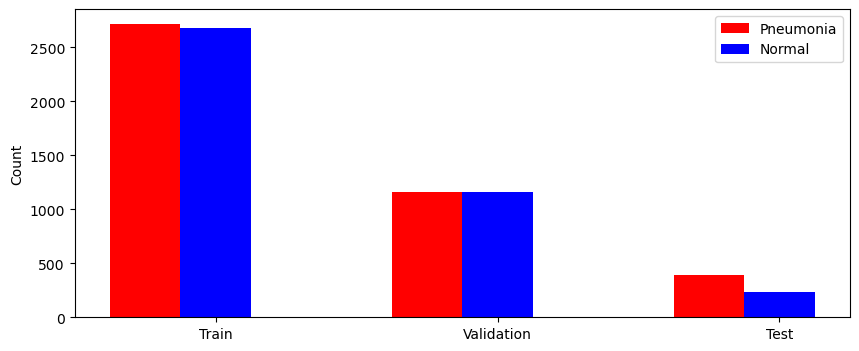

In [12]:
fig = plt.subplots(figsize =(10, 4))

br1 = np.arange(len(Pn))
br2 = [x + 0.25 for x in br1]

plt.bar(br1, Pn, color='r', width = 0.25, label = 'Pneumonia')
plt.bar(br2, No, color='b', width = 0.25, label = 'Normal')

plt.ylabel('Count')
plt.xticks([r + 0.25 for r in range(len(Pn))],
        ['Train', 'Validation', 'Test'])
plt.legend()
plt.show()

### Define the Model using pretrained models (resnet18, vgg16 etc)

In [13]:
model = torchvision.models.resnet18(pretrained=True)
#model = torchvision.models.vgg16(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, 2)
)
model= nn.DataParallel(model)
model.to(device)
summary(model, input_size = (3, 224, 224))

/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

### Define Trainer, Validation Loop

In [14]:
def trainer_loop(model, 
                 trainloader, 
                 loss_fn, 
                 optimizer, 
                 scheduler = None, 
                 t_gpu = True):
    model.train()
    tr_loss, tr_acc = 0.0, 0.0
    for i, data in enumerate(tqdm(trainloader)):
        img, label = data
        if t_gpu:
                img, label = img.cuda(), label.cuda()
        optimizer.zero_grad()
        output = model(img)
        _, pred = torch.max(output.data, 1)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()
        
        tr_loss += loss.item()
        tr_acc += torch.sum(pred == label.data)
        torch.cuda.empty_cache()

    scheduler.step() if scheduler != None else None
    return tr_loss/len(trainloader.dataset), 100*tr_acc/len(trainloader.dataset)

In [15]:
def val_loop(model, val_loader, loss_fn, t_gpu=True):
    model.train(False)
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for i, data in enumerate(tqdm(val_loader)):
            img, label = data
            if t_gpu:
                    img, label = img.cuda(), label.cuda()
            output = model(img)
            _, pred = torch.max(output.data, 1)
            loss = loss_fn(output, label)

            val_loss += loss.item()
            val_acc += torch.sum(pred == label.data)

    return val_loss/len(val_loader.dataset), 100*val_acc/len(val_loader.dataset)

In [16]:
def train_model(epochs, 
                model, 
                trainloader, 
                valloader, 
                loss_fn, 
                optimizer, 
                scheduler = None, 
                t_gpu = True):
    stat_dict = {
        'learning_rate':[],
        'train_loss':    [],
        'train_acc':     [],
        'val_loss':      [],
        'val_acc':       []    
    }
    print('*'*5+'Training Started'+'*'*5)
    for ep in range(epochs):
        print(f'Training epoch: {ep+1}')
        t_loss, t_acc = trainer_loop(
            model, trainloader, loss_fn, optimizer, scheduler, t_gpu
        )
        v_loss, v_acc = val_loop(
            model, valloader, loss_fn, t_gpu
        )
        print(f'Learning Rate: {optimizer.param_groups[0]["lr"]}')
        print(f'Training   : Loss: {t_loss}    Accuracy: {t_acc}%')
        print(f'Validation : Loss: {v_loss}    Accuracy: {v_acc}%')
        stat_dict['learning_rate'].append(optimizer.param_groups[0]["lr"])
        stat_dict['train_loss'].append(t_loss)
        stat_dict['val_loss'].append(v_loss)
        stat_dict['train_acc'].append(t_acc)
        stat_dict['val_acc'].append(v_acc)
    print('Finished Training')
    return stat_dict

### Define the Model parameters and execute the model on cuda

In [17]:
epochs = 100
alpha = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=alpha)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 
                                            step_size = 3, 
                                            gamma = 0.1)
loss_fn = nn.CrossEntropyLoss()

hist = train_model(epochs, 
                   model, 
                   Dataloaders['train'], 
                   Dataloaders['val'], 
                   loss_fn, 
                   optimizer,  
                   scheduler, 
                   device == 'cuda')

*****Training Started*****
Training epoch: 1


100%|██████████| 5/5 [00:01<00:00,  3.68it/s]


Learning Rate: 0.001
Training   : Loss: 0.000419084994181337    Accuracy: 90.41273498535156%
Validation : Loss: 0.0020444971703906544    Accuracy: 73.40242004394531%
Training epoch: 2


100%|██████████| 5/5 [00:01<00:00,  3.62it/s]


Learning Rate: 0.001
Training   : Loss: 0.00012699928353246707    Accuracy: 97.50138854980469%
Validation : Loss: 0.0018575452203783553    Accuracy: 75.94991302490234%
Training epoch: 3


...

Learning Rate: 1.0000000000000019e-35
Training   : Loss: 1.2683237727173672e-05    Accuracy: 99.98149108886719%
Validation : Loss: 7.773825612453187e-05    Accuracy: 98.66148376464844%
Training epoch: 99


100%|██████████| 5/5 [00:01<00:00,  3.52it/s]


Learning Rate: 1.000000000000002e-36
Training   : Loss: 1.3678641129693962e-05    Accuracy: 99.92596435546875%
Validation : Loss: 7.812992150095872e-05    Accuracy: 98.66148376464844%
Training epoch: 100


100%|██████████| 5/5 [00:01<00:00,  3.73it/s]

Learning Rate: 1.000000000000002e-36
Training   : Loss: 1.3304818668093325e-05    Accuracy: 99.94447326660156%
Validation : Loss: 7.784869907896753e-05    Accuracy: 98.66148376464844%
Finished Training


### Plot Train and Validation Loss

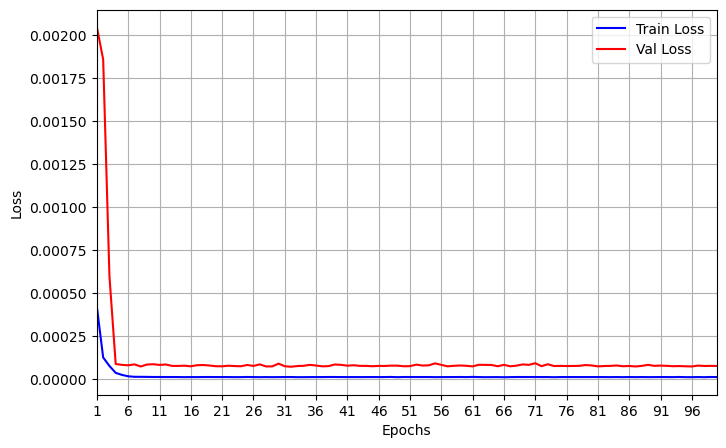

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

LT = ax.plot(np.linspace(1, epochs, epochs), hist['train_loss'], 'b-', label='Train Loss')
LV = ax.plot(np.linspace(1, epochs, epochs), hist['val_loss'], 'r-', label='Val Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

ax.set_xlim([1, (len(hist['val_loss']))])
if len(hist['val_loss']) >= 30:
    ax.set_xticks(range(1, (len(hist['val_loss'])+1), 5))
elif len(hist['val_loss']) >= 20:
    ax.set_xticks(range(1, (len(hist['val_loss'])+1), 2))
elif len(hist['val_loss']) < 20:
    ax.set_xticks(range(1, (len(hist['val_loss'])+1)))

lns = LT+LV
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper right')
ax.grid('on')

### Plot Train and Validation Accuracy

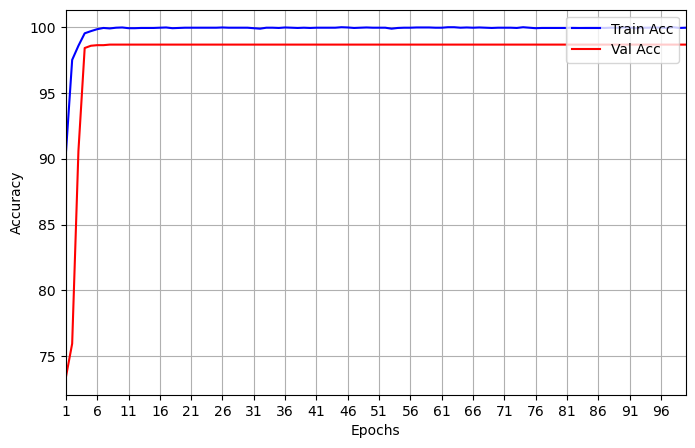

In [19]:
fig, ax = plt.subplots(figsize=(8,5))

hist_train = [hist['train_acc'][x].item() for x in range(len(hist['train_acc']))]
hist_val = [hist['val_acc'][x].item() for x in range(len(hist['val_acc']))]


AT = ax.plot(np.linspace(1, epochs, epochs), hist_train, 'b-', label='Train Acc')
AV = ax.plot(np.linspace(1, epochs, epochs), hist_val, 'r-', label='Val Acc')

ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy')

ax.set_xlim([1, (len(hist['val_acc']))])
if len(hist['val_acc']) >= 30:
    ax.set_xticks(range(1, (len(hist['val_acc'])+1), 5))
elif len(hist['val_acc']) >= 20:
    ax.set_xticks(range(1, (len(hist['val_acc'])+1), 2))
elif len(hist['val_acc']) < 20:
    ax.set_xticks(range(1, (len(hist['val_acc'])+1)))

lns = AT+AV
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper right')
ax.grid('on')

### Inference on Test Data

In [20]:
@torch.no_grad()
def test_loop(model, testdata, loss_fn, t_gpu):
    print('*'*5+'Testing Started'+'*'*5)
    model.train(False)
    model.eval()
    
    full_pred, full_lab = [], []
    
    TestLoss, TestAcc = 0.0, 0.0
    for data, target in testdata:
        if t_gpu:
            data, target = data.cuda(), target.cuda()
        model.to('cuda')
        output = model(data)
        loss = loss_fn(output, target)

        _, pred = torch.max(output.data, 1)
        TestLoss += loss.item() * data.size(0)
        TestAcc += torch.sum(pred == target.data)
        torch.cuda.empty_cache()
        full_pred += pred.tolist()
        full_lab += target.data.tolist()

    TestLoss = TestLoss / len(testdata.dataset)
    TestAcc = TestAcc / len(testdata.dataset)
    print(f'Loss: {TestLoss} Accuracy: {TestAcc}%')
    return full_pred, full_lab, output

In [21]:
testset = datasets.ImageFolder(test_folder, 
                           transform=transforms.Compose([transforms.Resize(255),
                                                 transforms.CenterCrop(224),                                                              
                                                 transforms.ToTensor(),
                                                ]))
test_dl = DataLoader(testset, batch_size=32)

In [22]:
pred, lab, output = test_loop(model, test_dl, loss_fn, True)

*****Testing Started*****
Loss: 0.37860067459181523 Accuracy: 0.9070512652397156%


### Look at the confusion matrix from the Test data prediction versus Actual labels.

<Figure size 640x480 with 0 Axes>

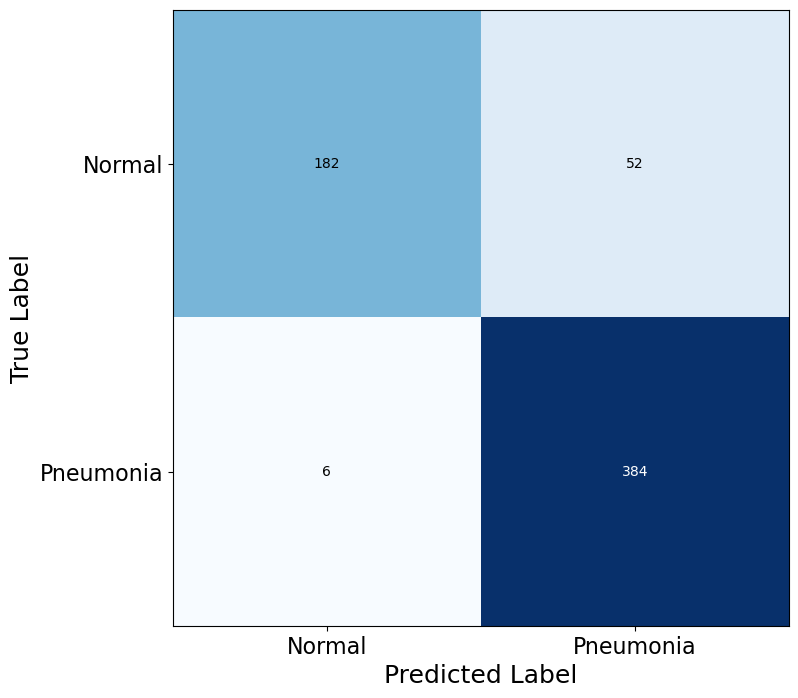

In [23]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

cm  = confusion_matrix(lab, pred)
plt.figure()
plot_confusion_matrix(cm,figsize=(12,8),cmap=plt.cm.Blues)
plt.xticks(range(2), ['Normal', 'Pneumonia'], fontsize=16)
plt.yticks(range(2), ['Normal', 'Pneumonia'], fontsize=16)
plt.xlabel('Predicted Label',fontsize=18)
plt.ylabel('True Label',fontsize=18)
plt.show()

### Get the Model Accuracy, Recall, Precision and F1 Score of the Model

In [24]:
tn, fp, fn, tp = cm.ravel()

accuracy = (np.array(pred) == np.array(lab)).sum() / len(pred)
precision = tp/(tp+fp)
recall = tp/(tp+fn)
f1 = 2*((precision*recall)/(precision+recall))

print("Accuracy of the model is {:.2f}".format(accuracy))
print("Recall of the model is {:.2f}".format(recall))
print("Precision of the model is {:.2f}".format(precision))
print("F1 Score of the model is {:.2f}".format(f1))

Accuracy of the model is 0.91
Recall of the model is 0.98
Precision of the model is 0.88
F1 Score of the model is 0.93


### Save the Trained Model

In [25]:
torch.save(model.state_dict(), 'pneumonia_detection.pt')

In [26]:
import onnx
model.eval()
dummy_input,_ = next(iter(Dataloaders['test']))
torch.onnx.export(model.module,
         dummy_input.cuda(),
         "pneumonia_detection.onnx",
         export_params=True,
         opset_version=10,
         do_constant_folding=True,
         input_names = ['modelInput'],
         output_names = ['modelOutput'],
         dynamic_axes={'modelInput' : {0 : 'batch_size'},
                                'modelOutput' : {0 : 'batch_size'}}) 
print(" ") 
print('Model has been converted to ONNX')

============= Diagnostic Run torch.onnx.export version 2.0.1+cu117 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

 
Model has been converted to ONNX


### Snowpark Session

In [34]:
# Create Snowflake Session object
connection_parameters = json.load(open('cred.json'))
session = Session.builder.configs(connection_parameters).create()
session.sql_simplifier_enabled = True

snowflake_environment = session.sql('SELECT current_user(), current_version()').collect()
snowpark_version = VERSION

# Current Environment Details
print('User                        : {}'.format(snowflake_environment[0][0]))
print('Role                        : {}'.format(session.get_current_role()))
print('Database                    : {}'.format(session.get_current_database()))
print('Schema                      : {}'.format(session.get_current_schema()))
print('Warehouse                   : {}'.format(session.get_current_warehouse()))
print('Snowflake version           : {}'.format(snowflake_environment[0][1]))
print('Snowpark for Python version : {}.{}.{}'.format(snowpark_version[0],snowpark_version[1],snowpark_version[2]))

User                        : KNADADUR
Role                        : "PARTNER_APPS_USER_ROLE"
Database                    : "NEMO_DB"
Schema                      : "PUBLIC"
Warehouse                   : "COMPUTE_WH"
Snowflake version           : 7.34.0
Snowpark for Python version : 1.8.0


### Log the Model in Snowflake Registry

In [28]:
from snowflake.ml.registry import model_registry
from snowflake.ml._internal.utils import identifier

db = identifier._get_unescaped_name(session.get_current_database())
schema = identifier._get_unescaped_name(session.get_current_schema())

model_name = "DICOM_pytorch_model_multigpu"
model_version = "v10"

registry = model_registry.ModelRegistry(session=session, database_name=db, schema_name=schema,create_if_not_exists=True)

registry.log_model(
    model_name=model_name,
    model_version=model_version,
    model=model.module.to('cpu'),
    sample_input_data=[val_ds[0][0].unsqueeze(0)],
    # sample_input_data=[val_ds[0][0].unsqueeze(0).to(device)],
    conda_dependencies=["absl-py",
                        "anyio",
                        "cloudpickle",
                        "numpy",
                        "packaging",
                        "pandas",
                        "pyyaml",
                        "snowflake-snowpark-python",
                        "typing-extensions",
                        "pytorch",
                        "torchvision"],
    options={"embed_local_ml_library": True, # This option is enabled to pull latest dev code changes.
             "relax": True}, # relax dependencies
)

create_model_registry() is in private preview since 0.2.0. Do not use it in production. 


### Check Model Registered

In [36]:
session.sql("select creation_time, ID, NAME, TYPE, URI, VERSION from _SYSTEM_REGISTRY_MODELS").show(20)

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"CREATION_TIME"                   |"ID"                              |"NAME"                        |"TYPE"   |"URI"                                               |"VERSION"  |
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2023-09-26 21:53:36.376000-07:00  |cf0767885cf111ee91039633d979f339  |DICOM_pytorch_model           |pytorch  |sfc://NEMO_DB.PUBLIC.SNOWML_MODEL_CF0767885CF11...  |v1         |
|2023-09-26 22:10:30.242000-07:00  |2b63db725cf411ee91039633d979f339  |DICOM_pytorch_model_multigpu  |pytorch  |sfc://NEMO_DB.PUBLIC.SNOWML_MODEL_2B63DB725CF41...  |v1         |
|2023-09-26 23:06:22.742000-07:00  |f8f7c86c5cfb11ee91039633d979f339  |DICOM_pytorch_model_multigpu  |pytorch 

In [37]:
session.close()